Frozen retrieval final counts:
  Attractor 0: 200
  Attractor 1: 0
  Attractor 2: 0
Plastic retrieval final counts:
  Attractor 0: 175
  Attractor 1: 25
  Attractor 2: 0


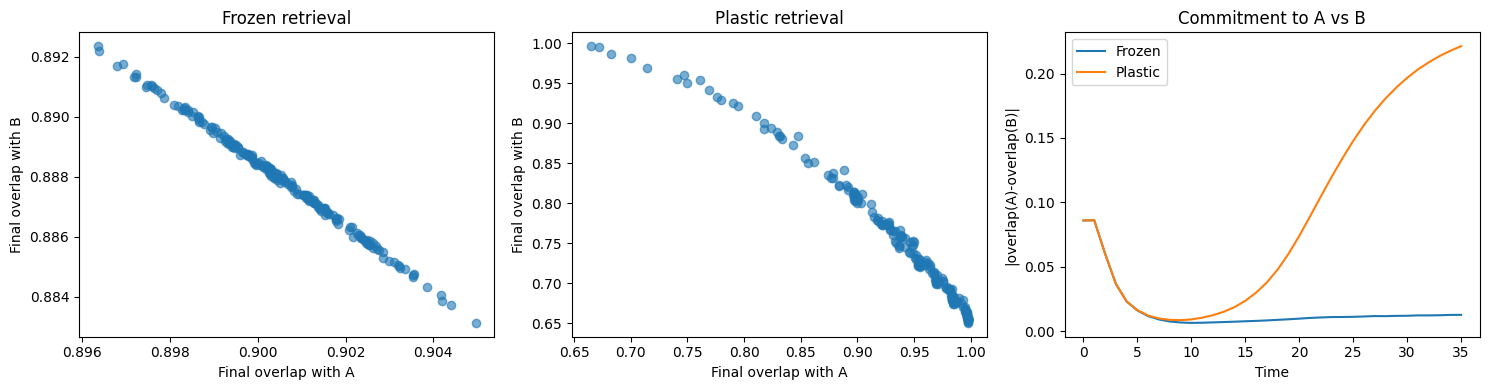

In [2]:
import numpy as np
import matplotlib.pyplot as plt


class RetrievalMultistableNet:
    def __init__(
        self,
        n_units=80,
        eta=0.006,          # smaller than before
        plastic_decay=0.08, # fast decay so plasticity is local/transient
        state_leak=0.25,
        noise_std=0.04,
        gain=1.4,
        seed=0,
    ):
        self.n_units = n_units
        self.eta = eta
        self.plastic_decay = plastic_decay
        self.state_leak = state_leak
        self.noise_std = noise_std
        self.gain = gain
        self.rng = np.random.default_rng(seed)

        self.patterns = self._make_patterns()
        self.W0 = self._make_base_weights()

    def _make_patterns(self):
        # Pattern A
        A = self.rng.choice([-1.0, 1.0], size=self.n_units)

        # Pattern B: correlated with A
        B = A.copy()
        flip_idx = self.rng.choice(self.n_units, size=self.n_units // 5, replace=False)
        B[flip_idx] *= -1.0

        # Pattern C: unrelated
        C = self.rng.choice([-1.0, 1.0], size=self.n_units)

        return np.stack([A, B, C], axis=0)

    def _make_base_weights(self):
        # Make A and B both strong, C weaker
        coeffs = [1.0, 1.0, 0.35]
        W = np.zeros((self.n_units, self.n_units))
        for c, p in zip(coeffs, self.patterns):
            W += c * np.outer(p, p)
        W /= self.n_units
        np.fill_diagonal(W, 0.0)
        return W

    def overlaps(self, x):
        xnorm = np.linalg.norm(x) + 1e-9
        vals = []
        for p in self.patterns:
            vals.append(np.dot(x, p) / ((np.linalg.norm(p) + 1e-9) * xnorm))
        return np.array(vals)

    def run_trial(self, T=35, plastic=False):
        # Ambiguous cue: midway between A and B
        cue = 0.55 * self.patterns[0] + 0.55 * self.patterns[1]
        cue = cue / (np.linalg.norm(cue) + 1e-9)

        # Initial state near neutral
        x = 0.08 * self.rng.normal(size=self.n_units)

        Wp = np.zeros_like(self.W0)
        traj = [x.copy()]
        ov_traj = [self.overlaps(x)]

        for t in range(T):
            W = self.W0 + Wp

            # Small time-varying noise
            noise = self.rng.normal(0, self.noise_std, size=self.n_units)

            h = W @ x + 0.9 * cue + noise
            x_new = np.tanh(self.gain * h)

            # leaky dynamics
            x = (1 - self.state_leak) * x + self.state_leak * x_new

            if plastic:
                # Gate plasticity by ambiguity between A and B:
                ov = self.overlaps(x)
                ambiguity = 1.0 - np.abs(ov[0] - ov[1])  # high when A/B are similarly likely
                ambiguity = np.clip(ambiguity, 0.0, 1.0)

                dWp = self.eta * ambiguity * np.outer(x, x)
                Wp = (1 - self.plastic_decay) * Wp + dWp
                np.fill_diagonal(Wp, 0.0)

                # Bound the plastic term so it cannot overwrite the whole landscape
                Wp = np.clip(Wp, -0.6 / self.n_units, 0.6 / self.n_units)

            traj.append(x.copy())
            ov_traj.append(self.overlaps(x))

        final_ov = self.overlaps(x)
        label = int(np.argmax(final_ov))
        return np.array(traj), np.array(ov_traj), final_ov, label


def run_many(n_trials=200, plastic=False, seed=0):
    net = RetrievalMultistableNet(seed=seed)
    labels = []
    finals = []
    traces = []

    for _ in range(n_trials):
        traj, ov_traj, final_ov, label = net.run_trial(plastic=plastic)
        labels.append(label)
        finals.append(final_ov)
        traces.append(ov_traj)

    return net, np.array(labels), np.array(finals), np.array(traces)


def summarize(labels, title):
    counts = np.bincount(labels, minlength=3)
    print(title)
    for i, c in enumerate(counts):
        print(f"  Attractor {i}: {c}")


def plot_results(finals_fixed, finals_plastic, traces_fixed, traces_plastic):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Final overlaps on A vs B
    axes[0].scatter(finals_fixed[:, 0], finals_fixed[:, 1], alpha=0.6)
    axes[0].set_title("Frozen retrieval")
    axes[0].set_xlabel("Final overlap with A")
    axes[0].set_ylabel("Final overlap with B")

    axes[1].scatter(finals_plastic[:, 0], finals_plastic[:, 1], alpha=0.6)
    axes[1].set_title("Plastic retrieval")
    axes[1].set_xlabel("Final overlap with A")
    axes[1].set_ylabel("Final overlap with B")

    # Mean difference |A-B| over time
    d_fixed = np.abs(traces_fixed[:, :, 0] - traces_fixed[:, :, 1])
    d_plastic = np.abs(traces_plastic[:, :, 0] - traces_plastic[:, :, 1])

    axes[2].plot(d_fixed.mean(axis=0), label="Frozen")
    axes[2].plot(d_plastic.mean(axis=0), label="Plastic")
    axes[2].set_title("Commitment to A vs B")
    axes[2].set_xlabel("Time")
    axes[2].set_ylabel("|overlap(A)-overlap(B)|")
    axes[2].legend()

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    net, labels_fixed, finals_fixed, traces_fixed = run_many(
        n_trials=200, plastic=False, seed=1
    )
    _, labels_plastic, finals_plastic, traces_plastic = run_many(
        n_trials=200, plastic=True, seed=1
    )

    summarize(labels_fixed, "Frozen retrieval final counts:")
    summarize(labels_plastic, "Plastic retrieval final counts:")

    plot_results(finals_fixed, finals_plastic, traces_fixed, traces_plastic)